In [1]:
import tensorflow as tf
print("TF", tf.__version__)
from matplotlib import animation, rc
import matplotlib.pyplot as plt
from IPython.display import HTML, display_html
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import clear_output, display_html, HTML
import contextlib
import time
import io
import urllib
import base64

I0000 00:00:1778942220.058487  201071 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF 2.21.0


In [2]:
def clear_and_display_figure(fig, sleep=0.01):
    img_data = io.BytesIO()
    fig.savefig(img_data, format='jpeg')
    img_data.seek(0)
    uri = 'data:image/jpeg;base64,' + urllib.request.quote(base64.b64encode(img_data.getbuffer()))
    img_data.close()
    clear_output(wait=True)
    display_html(HTML('<img src="' + uri + '">'))
    time.sleep(sleep)

# запись анимации для Колаба
class SimpleMovieWriter(object):
    """
    Usage example:
        anim = animation.FuncAnimation(...)
        anim.save(None, writer=SimpleMovieWriter(sleep=0.01))
    """
    def __init__(self, sleep=0.1):
        self.sleep = sleep

    def setup(self, fig):
        self.fig = fig

    def grab_frame(self, **kwargs):
        clear_and_display_figure(self.fig, self.sleep)

    @contextlib.contextmanager
    def saving(self, fig, *args, **kwargs):
        self.setup(fig)
        try:
            yield self
        finally:
            pass

Лосс на одном объекте: $l = (x_1 w_1 + x_2 w_2 - y)^2$

[Каноническое уравнение эллипса](https://ru.wikipedia.org/wiki/Эллипс): $\frac{x_1^2}{a^2} + \frac{x_2^2}{b^2} = 1$, поэтому [линии уровня](https://foxford.ru/wiki/matematika/metod-liniy-urovnya) лосса так выглядят.

Если мы будем увеличивать масштаб $x_1$, это будет сплющивать ось $w_1$ на графике линий уровня.

Разные по масштабу градиенты если разный масштаб признаков:

$ \frac{dl}{dw_1} = 2 (x_1 w_1 + x_2 w_2 - y) x_1$

$ \frac{dl}{dw_2} = 2 (x_1 w_1 + x_2 w_2 - y) x_2$

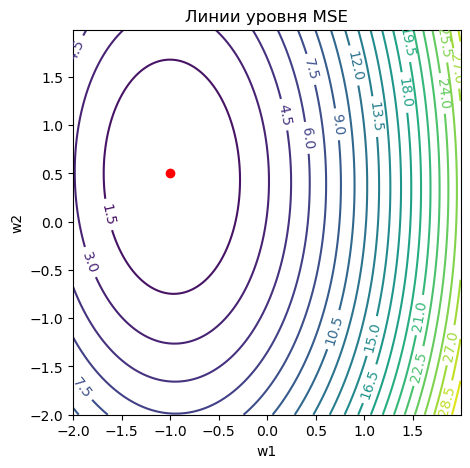

In [3]:
# генерируем простой датасет
np.random.seed(42)
N = 100
x = np.random.randn(N, 2)
w = np.array([[-1, 0.5]]).T
x[:, 0] *= 2  # признак x1 в x_scale раз больше (создает долины в лоссе)
y = x @ w + np.random.randn(N, 1) * 0.2
    
# рисуем линии уровня лосса в пространстве весов
fig, ax = plt.subplots(figsize=(5, 5))
W1, W2 = np.meshgrid(np.arange(-2, 2, 0.01), np.arange(-2, 2, 0.01))
Z = np.mean((x.dot(np.vstack([W1.ravel(), W2.ravel()])) - y)**2, axis=0).reshape(W1.shape)
contour = ax.contour(W1, W2, Z, 20)
ax.scatter(*w, c='red')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title(u"Линии уровня MSE")
ax.clabel(contour, inline=1, fontsize=10);

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def plot_gd(x_scale, lr, steps, optimizer_name='sgd', start_w = None):
    # генерируем простой датасет
    np.random.seed(42)
    N = 100
    x = np.random.randn(N, 2).astype(np.float32)
    w = np.array([[-1, 0.5]], dtype=np.float32).T
    x[:, 0] *= x_scale  
    y = x @ w + np.random.randn(N, 1).astype(np.float32) * 0.2

    # Инициализация весов
    if start_w is None:
        w_guess = tf.Variable([[1.5], [1.5]], dtype=tf.float32)
    else:
        w_guess = tf.Variable([[float(start_w[0])], [float(start_w[1])]], dtype=tf.float32)
        
    # Инициализация оптимизатора для Keras 3
    optimizer = tf.keras.optimizers.get({
        "class_name": optimizer_name, 
        "config": {"learning_rate": lr}
    })
    
    # Современный шаг оптимизации через GradientTape (взамен .minimize)
    def optimization_step():
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean((x @ w_guess - y) ** 2)
        grads = tape.gradient(loss, [w_guess])
        optimizer.apply_gradients(zip(grads, [w_guess]))
        
    def get_w_guess():
        # Возвращает массив [w1, w2]
        return w_guess.numpy().flatten()

    # Рисуем линии уровня лосса
    fig, ax = plt.subplots(figsize=(5, 5))
    W1, W2 = np.meshgrid(np.arange(-2, 2, 0.01), np.arange(-2, 2, 0.01))
    Z = np.mean((x.dot(np.vstack([W1.ravel(), W2.ravel()])) - y)**2, axis=0).reshape(W1.shape)
    contour = ax.contour(W1, W2, Z, 20)
    ax.scatter(w[0], w[1], c='red', zorder=5, label='Target')
    ax.clabel(contour, inline=1, fontsize=10)
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title("Линии уровня MSE")
    
    # Отрисовка линии траектории
    line, = ax.plot([], [], lw=2, color='blue', marker='o', markersize=4)

    def init():
        line.set_data([], [])
        return (line,)

    # Списки для хранения координат траектории
    init_w = get_w_guess()
    trajectory_x = [init_w[0]]
    trajectory_y = [init_w[1]]

    def animate(i):
        optimization_step()
        curr_w = get_w_guess()
        trajectory_x.append(curr_w[0])
        trajectory_y.append(curr_w[1])
        line.set_data(trajectory_x, trajectory_y)
        return (line,)

    # Создаем анимацию
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=steps, interval=150, blit=True)

    plt.close(fig) # Закрываем фигуру во избежание лишних графиков
    return anim


# Простой SGD

У наивного SGD есть проблемы, он плохо сходится когда производные по разным весам слишком разные по масштабу!

In [15]:
plot_gd(x_scale=1.0, lr=0.1, steps=25)

In [16]:
# Запуск анимации интерактивно в ячейке ноутбука
anim = plot_gd(x_scale=1.0, lr=0.1, steps=25)
HTML(anim.to_html5_video())


In [18]:
# узкие долины функции
anim = plot_gd(x_scale=0.5, lr=0.1, steps=25)
HTML(anim.to_html5_video())

In [19]:
# еще более узкие
anim = plot_gd(x_scale=0.2, lr=0.1, steps=25)
HTML(anim.to_html5_video())

In [20]:
# попробуем шаг побольше?
# w0 меняется быстрее, но w1 меняется слишком быстро, приводит к осциллированию
anim = plot_gd(x_scale=0.2, lr=1.0, steps=25)
HTML(anim.to_html5_video())

# Adam

Адам работает как зайка, ему не важен масштаб признаков, у него адаптивный learning rate и инерция!

In [22]:
anim = plot_gd(x_scale=1.0, lr=0.1, steps=25, optimizer_name='adam')
HTML(anim.to_html5_video())

In [23]:
anim = plot_gd(x_scale=1.0, lr=0.1, steps=25, optimizer_name='adam', start_w = [1.5, 0.5])
HTML(anim.to_html5_video())

In [24]:
# узкие долины функции
anim = plot_gd(x_scale=0.5, lr=0.1, steps=25, optimizer_name='adam')
HTML(anim.to_html5_video())

In [25]:
# еще более узкие
anim = plot_gd(x_scale=0.2, lr=0.1, steps=25, optimizer_name='adam')
HTML(anim.to_html5_video())

In [26]:
# сломает ли его шаг побольше?
# слишком большие шаги, закручиваемся вокруг решения из-за момента
anim = plot_gd(x_scale=0.2, lr=0.8, steps=25, optimizer_name='adam')
HTML(anim.to_html5_video())

Если хочется почитать подробнее: 

*   http://cnl.salk.edu/~schraudo/teach/NNcourse/precond.html
*   https://emiliendupont.github.io/2018/01/24/optimization-visualization/